# V1 L4 model with Apache Cerebrum 

This notebook walks through the  Cerebrum workflow to construct
a simple *V1* model that restricted to only the layer *L4*.
The notebook 
- overviews the data sources configuration,
- explore the downloaded data,
- build the model from code,
- run the simulation, and finally 
- visualize the simulation outputs.  

### Structure of Cerebrum Workflow

Cerebrum follows the following workflow when building a computational brain model
from data acquired from large databases 

<div>
<img src="img/Workflow.png" width="400"/>
</div>


The workflow steps to construct a model in Cerebrum are as follows (as shown in the figure above): 

1. Query and download the requisite data from public databases.
   In case of V1 L4, we acquire data from the following databases:
     - Allen Model Database,
     - Allen Brain Atlas
     - Synaptic Physiology datasets. 
3. Map the acquired data to the relevant regions of the model to be built. 
4. Fill-in any missing details via an optional user-defined **custom mod** definitions. 
5. Realize the final network of neurons in the SONATA format.


### Model Recipe

Model Recipe (files in sub-folder `recipes/v1`) defines key components for constructing a Network of neurons with Cerebrum. 

- **Data Providers:** Links to source database and query parameters
- **Filter and Transformers:** Data processing workflow such as filtering via selection criteria on the queried data.
- **Data2Model Mappers:** Mapper methods that map data to model components.
- **User Modifications:** Descriptions of user additions/removals to the purely data-driven model

The following figure shows the overall structure of a Model recipe definition.

<div>
<img src="img/Recipe.png" width="600"/>
</div>

## Install dependencies in a `conda` environment 

The Notebook is expected to be run in a `conda` environment,
in which `cerebrum` and other dependcies installed. 
See the [README.md](README.md) file for the instructions to
create the environment.


In [1]:
from airavata_cerebrum.recipe import RecipeSetup, ModelRecipe
from airavata_cerebrum.model.structure import Network
from airavata_cerebrum.view.tree import DataSourceRecipeView, Data2ModelRecipeView, NetworkStructureView
#
from src import model as v1model
from src import operations as v1ops
from src import lfour_params as v1params
#
import nest
from nest.lib.hl_api_sonata import SonataNetwork
from nest.lib.hl_api_nodes import Create as NestCreate
from nest.lib.hl_api_connections import Connect as NestConnect
from nest.lib.hl_api_types import NodeCollection


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0-rc.2
 Built  : May  7 2026 05:58:33

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



# V1 L4 Model Recipe

The Cerebrum V1 L4 model recipe includes the following three sections.
For V1, the model recipe is defined by a collection of human-readable
json files under the recipe directory `recipes/v1`.

1. **source_data**
    - Describes how the source databases are connected
    - Defines what operations applied to the data such as filters etc
    - For V1 L4, the `recipes/v1l4/source_data.json` file contains
      the **source_data** section.
2. **data2model_map**
    - Describes mapping between source data and different
      regions/segments of the model.
    - For V1 L4, `recipes/v1l4/recipe.json` contains the
      **data2model_map** section.
3. **custom mod**
    - Describes the user modifications applied after a model skeleton
      build from the data and mapping ((1) and (2) above).
    - For V1 L4, we have eight different custom mod files,
      `recipes/v1l4/custom_mod.json` contains the user
       **cust mod**s for L4 layer and the BKG and LGN layers.

***NOTE: The following code loads all the above recipe files an
initializes a python `ModelSetup` object that performs basic input
validation, and captures all the parameters. Custom modifications
are loaded separately as a `cerebrum.structure.Network` object.***

In [3]:
#
# The following code initializes the parameters of the model
params = v1params.RecipeParams()
params.ncells = 4000
#
# After setting the model parameters, we create a ModelSetup object
# that builds a framework with some simple valiations
md_recipe_setup = params.recipe_setup()

#
# Custom mods are built as a separate object, which will be 
# combined later after a skeleton is built.
custom_mod_struct = Network.from_file_list(params.custom_mod) 

In [5]:
import IPython.display
import json
with open("./recipes/v1l4/recipe.json") as ifx:
    config_dict = json.load(ifx)
IPython.display.JSON(config_dict)

<IPython.core.display.JSON object>

## Exploring the Source Data Section

Cerebrum includes modules that can download data from multiple
data provider modules. It includes
- Methods for defining the querying from the database and
  filter the data based on specific criteria. 
- Utilities to visualize the data provider configurations in
  easy-to-understand explorer view inside Jupyter notebook
  with the relevant parameters displayed in the side panel.

Cerebrum Construction of Mouse V1 is enabled by data with 
three different data providers: 
- Allen Cell Types database,
- Allen Brain Cell Atlas,
- AI Synaptic Physiology Database, and
- Gouwens et. al. (2019) neuron classification based on
  electrophysiolocial data.

***NOTE: Running code below within the jupyter notebook will display the tree structure of the recipe's source_data section***

In [6]:
import IPython.display
##
## Displays in the ipython notebook, the structure of source data
IPython.display.JSON(md_recipe_setup.get_section('source_data'))

<IPython.core.display.JSON object>

### Visualize Source Data

Cerebrum also provides a Jupyter Notebook Widgets that
aids the visualization of the source data configration.
The `DataSourceRecipeView` renders the data source 
information and query parameters in a user friendly output
as compared to the strict names in json file. 

<div>
<img src="img/L4SourceData.png" width="800"/>
</div>

**NOTE: Running the code below with show an interactive explorer-like tree structure as shown in the image above**

In [8]:
sd_tree = DataSourceRecipeView(md_recipe_setup, left_width="55%")
sd_tree.build()
sd_tree.layout

TwoByTwoLayout(children=(<awitree.Tree object at 0x15543779bc70>,), layout=Layout(grid_template_areas='"top-le…

## Data2Model Mapping

`data2model_map` section of the recipe includes two subsections:

1. *Locations:*
    - Locations are hiearchially defined and each sub-location
      declares the links to the acquired data.
    - For V1 L4, (i) acquired cell types information from Cell types
      database maps to the neuron models, and
      (ii) the summary information from MERFISH single-cell atlas
      map to the distribution of neuron types.
    - For V1 L4, we map eight different neuron types to the specific
      models and the region fractions. 
2. *Connections:*
    - Connections are defined as a set of pairs to neurons,
      with pair defining the data links.
    - AI synaptic physiology data is mapped to the connection
      probabilities between the pairs of neuron classes.
    - For V1 L4, we map each of the different neuron pairs to the
      AI Syn. Phys. Data outputs

***NOTE: Running code below within the jupyter notebook will display
the josn hierachia-structure of the recipe's data2model section***

In [9]:
import IPython.display

IPython.display.JSON(md_recipe_setup.get_section('data2model_map'))

<IPython.core.display.JSON object>

### Visualize Data2Model Mapping
Similar to Source Data section, Cerebrum also provides a Jupyter Notebook Widget
to visualize the data2model section of the recipe.
The `Data2ModelRecipeView` renders with a user friendly output compared to
the strict names in json file. 

<div>
<img src="img/L4SrcLocations.png" width="400"/>
<img src="img/L4SrcConnections.png" width="400"/>
</div>

***NOTE: Running the Recipe View code below will display the Tree widget (as shown in the above snapshot), when run inside the Jupyter notebook***

In [10]:
dm_tree = Data2ModelRecipeView(md_recipe_setup, width="55%")
dm_tree.build()
dm_tree.layout

TwoByTwoLayout(children=(<awitree.Tree object at 0x155436cb48e0>,), layout=Layout(grid_template_areas='"top-le…

## Custom Modifications

Through the custom modification json files,users can
provide additional details required for network
construction. They can include information that are either
(a) not available in the linked databases or
(b) not applicable for the model being built and over-ride it.

For the Mouse V1 L4, custom modifications include:

1. Dimensions of each region in the model.
2. Connection Parameters not available within the AI Syn. Phys. database.
3. Details of the networks that are external to V1 : LGN and the background networks. 


***NOTE: Running code below within the jupyter notebook will display the
tree structure of the data2model section from the json files***

In [11]:
import IPython.display

IPython.display.JSON(custom_mod_struct.model_dump())

<IPython.core.display.JSON object>

### Visualize Custom Mod structure

Similar to Source Data section, Cerebrum also provides a Jupyter
Notebook Widget based visualization of the custom modifications.
The `NetworkStructureView` renders with user friendly output
compared to the strict names in json file.

<img src="img/L4CustomMod.png" width=600/>

**NOTE::**
1. ***Running the Recipe View code below will display the Tree widget
(as shown in the above snapshot), when run inside the Jupyter notebook***
2. ***Due to Size Restrictions, this view doesn't work in ipython for now
(It does work with marimo)***

In [ ]:
cmod_view = NetworkStructureView(custom_mod_struct, left_width="55%")
cmod_view.build()
cmod_view.layout

## Mapper classess for  Network construction
To realize model recipe to SONATA Network, three python classes that translate from the model skeleton to neurons and connections.

1. *Region Mapper* : Defined in `mousev1.model.V1RegionMapper`, maps the location data gathered from data sources/user mods to a region in the network.
2. *Neuron Mapper* : Defined in `mousev1.model.V1NeuronMapps`, maps the neuron information within in a given location data to a neuron class within the region.
3. *Connection Mapper*: Defined in `mousev1.model.V1ConnectionMapper`, maps the connection data to realize the connection details in the network of neurons.

In addition a *Network Builder* class (`mousev1.model.V1BMTKNetworkBuilder`) is also defined that translates the model description to SONATA network. 

In [14]:
from src.model import (
    V1BMTKNetworkBuilder,
    V1ConnectionMapper,
    V1NeuronMapper,
    V1RegionMapper
)

model_recipe = ModelRecipe(
    recipe_setup=md_recipe_setup,
    region_mapper=V1RegionMapper,
    neuron_mapper=V1NeuronMapper,
    connection_mapper=V1ConnectionMapper,
    network_builder=V1BMTKNetworkBuilder,
    mod_structure=custom_mod_struct,
    save_flag=params.save_flag,
)
# logging.basicConfig(level=logging.INFO)

# V1 L4 Network Construction from Recipe

## Data Acquistition

Data acquisition consists of the following two steps: 
1. Data download and 
2. Data transformer operations such as filtering and combining
   that are run after downloaded data. 

### Run Workflow to Download Data

After the model description is defined and updated with
custom user modifications, the download workflow proceeds as follows:
1. Query and download the data from all the databases of interest.
2. Apply the filters and transormations.
3. Save downloaded data to a local database.

### Run Post-download Operations

After data is dowloaded, the data obtained from 
different databases need to processed separately:

1.  In case of the Allen Cell Type database, the download step can
    be restricted only to obtain the metadata related to cell types.
    After the meta data is downloaded, we need to acquire the models
    of interest (3 LIF Models). We use the GLIF API from allensdk to
    download these 3LIF model with a explained variance threshold.
    Further filter is applied based on the classification by
   *Gouwens et. al. (2019)*.
3.  For data from Allen Brain Cell Atlas,
    we filter the data specific to only the VISp region.
5.  For AI Syn Phys. data, we select only the neuron pairs of our interest.

We accomplish the above two steps by running `recipe.acquire_source_data()` function as below.

**NOTE:: Uncomment the logging configuration to get detailed logging**

In [15]:
#
# UNCOMMENT THE FOLLOWING TO GET detailed logging
#
#import logging
#logging.basicConfig(level=logging.INFO)
import warnings

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    db_source_data = model_recipe.acquire_source_data()

  0%|          | 0/2333 [00:00<?, ?it/s]

## Explore downloaded data

Output data are stored in the description directory in
json format in `data/v1l4/db_connect_output.json`, which
can be examine with json library. Here are examples of
Region and Neuron fractions of the Allen Brain Atlas, and
connectivity matrix downloaded from AI Syn. Phys. dataset. 

Output data is also stored as **duckdb** database
`data/v1l4/db_connect_output.db`, which can be used for
detailed queries.

In [16]:
import json
#
#
with open("./data/v1l4/db_connect_output.json") as dbf:
    db_out_data = json.load(dbf)

### Regional Neuron Distributions from Mouse Brain Atlas

In [17]:
import airavata_cerebrum.dataset.abc_mouse as abcm
abcm.DFBuilder.build(db_out_data['airavata_cerebrum.dataset.abc_mouse'])

Region,Layer,nregion,inhibitory fraction,fraction wi. region,Vip fraction,Pvalb fraction,Sst fraction,Lamp5 fraction,Sst-Chodl fraction,IT-ENT fraction,IT-CTX fraction,IT-Other fraction,ET fraction,CT fraction,NP fraction,IT fraction
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""VISp""","""1""",61884,0.405155,0.069663,0.147583,0.038168,0.035623,0.720102,0.007634,0.001733,0.986135,0.001733,0.0,0.0,0.0,0.989601
"""VISp""","""2/3""",61884,0.078755,0.34862,0.31669,0.332382,0.161912,0.158345,0.00214,0.0,1.0,0.0,0.0,0.0,0.0,1.0
"""VISp""","""4""",61884,0.111916,0.209699,0.131933,0.532773,0.315126,0.018487,0.0,0.0,0.962618,0.0,0.029334,0.000212,0.007413,0.962618
"""VISp""","""5""",61884,0.165428,0.177606,0.021739,0.487681,0.455797,0.022464,0.006522,0.001867,0.519247,0.000144,0.323039,0.043953,0.104137,0.521258
"""VISp""","""6a""",61884,0.062779,0.163661,0.038321,0.562044,0.34854,0.025547,0.010949,0.001711,0.212443,0.001834,0.000611,0.75932,0.005378,0.215988
"""VISp""","""6b""",61884,0.05291,0.030751,0.0375,0.475,0.275,0.0875,0.075,0.0,0.042598,0.00419,0.0,0.725559,0.0,0.046788


### Connectivity probability from AI Syn. Phys.

In [18]:
import airavata_cerebrum.dataset.ai_synphys as aisp
aisp.DFBuilder.build(db_out_data['airavata_cerebrum.dataset.ai_synphys'])

pre_synapse,post_synapse,connect_prob
str,str,f64
"""L4-Pyr""","""L4-Pyr""",0.125985
"""L4-Pyr""","""L4-Pvalb""",0.198113
"""L4-Pyr""","""L4-Sst""",0.045855
"""L4-Pyr""","""L4-Vip""",0.049624
"""L4-Pvalb""","""L4-Pyr""",0.356604
…,…,…
"""L4-Sst""","""L4-Vip""",0.306504
"""L4-Vip""","""L4-Pyr""",0.0
"""L4-Vip""","""L4-Pvalb""",0.025412


## Mapping Source data

In this step, the data downloaded is mapped to the locations and the connection pairs as mentioned in "Data2Model Map" section above.

A snapshot of the mapping is shown below:

<img src="img/L4SrcLocations.png" /> <img src="img/L4SrcConnections.png" />


In [19]:
#import logging
#logging.basicConfig(level=logging.INFO)
#
msrc = model_recipe.map_source_data()

## Apply User Modifications

As mentioned in the "Custom Modifications" section above,
user updates for the model are loaded from
`./recipes/v1l4/custom_mod.json`.

For V1 L4, the user modification include the dimensions,
connection properties, and details about the external netowrks

In [20]:
import IPython.display
import json
with open(params.custom_mod_main) as ifx:
    custom_mod_dict = json.load(ifx)
IPython.display.JSON(custom_mod_dict)

<IPython.core.display.JSON object>

In [21]:
msrc = model_recipe.build_net_struct()
msrc = model_recipe.apply_mod(params.ncells)

## Build Network with BMTK 

### Skeleton Network → Graph of neurons

In this step this configuation is used to initialize the nodes and edges based on the data downloaded and custom modifications applied.

***NOTE:: The code below skips saving the file as saving consumes significant amount of time. Building first is useful to first verify any errors***

In [23]:
bmtk_net_builder = V1BMTKNetworkBuilder(model_recipe.network_struct)
bmtk_net = bmtk_net_builder.build()

### Save SONATA

Save SONATA with BMTK

***NOTE:: Skipping Save SONTA as it takes a siginificant amount of time. (Previously built files are made available in "./builds/v1l4" folder)*** 

In [ ]:
bmtk_net_builder.save(str(md_recipe_setup.network_dir))
bmtk_net_builder.bkg_net.save(str(mdr_setup.network_dir))

# V1 L4 Simulation with NEST
## Prepare neuron model files for NEST

The format of the glif properties json files downloaded by Cerebrum
from the cell types database is different from the format of what is expected by NEST. 

In this step, we run the format conversion utility.

In [ ]:
# Converting to 
import src.operations as ops
import nest
import matplotlib.pyplot as plt
import os

output_path = "./components/cell_models/"
input_path = "./components/point_neuron_models/"

if not os.path.exists(output_path):
    os.mkdir(output_path)

ops.convert_ctdb_models_to_nest(output_dir=output_path, input_dir=input_path)

## SONATA Config File

This NEST config file is manually created, and refers to the network files generated by Cerebrum.
We explore the config file below. 

In [25]:
import json
import IPython.display

with open("./builds/v1l4//config_nest.json") as ifx:
    cfg_dict = json.load(ifx)

IPython.display.JSON(cfg_dict)

<IPython.core.display.JSON object>

## Running Simulation with NEST

In [2]:
config_file = "./builds/v1l4/config_nest.json"
# Instantiate SonataNetwork
sonata_net = SonataNetwork(config_file)

# Create and connect nodes
node_collections = sonata_net.BuildNetwork()
print("Node Collections", node_collections.keys())

[INFO] [2026-06-04 14:36:44] Default for delta_tau changed from 0.1 to 0.25 ms
[INFO] [2026-06-04 14:36:44] Temporal resolution changed from 0.1 to 0.25 ms.
Node Collections dict_keys(['v1l4', 'bkg'])


In [3]:
# Connect spike recorder to a population

spike_rec = nest.Create("spike_recorder")
nest.Connect(node_collections["v1l4"], spike_rec)

# Attach Multimeter
multi_meter = nest.Create(
    "multimeter",
    params={
        # "interval": 0.05,
        "record_from": ["V_m", "I", "I_syn", "threshold", "threshold_spike", "threshold_voltage", "ASCurrents_sum"],
    },
)
nest.Connect(multi_meter, node_collections["v1l4"])

# Simulate the network
sonata_net.Simulate()

[INFO] [2026-06-04 14:36:53] Preparing 6489 nodes for simulation.
[INFO] [2026-06-04 14:36:53] Number of local nodes: 6489
Simulation time (ms): 3000
Number of OpenMP threads: 1
Not using MPI
[INFO] [2026-06-04 14:37:04] Simulation finished.


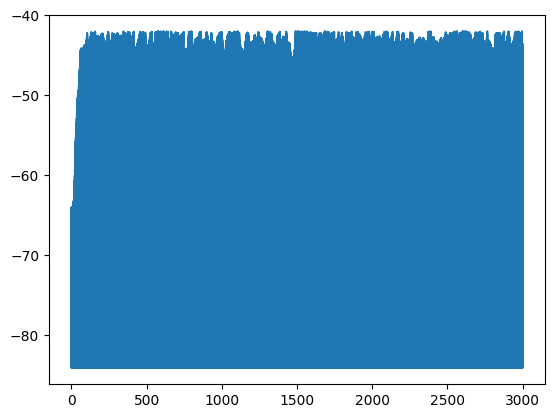

In [5]:
import matplotlib.pyplot as plt

dmm = multi_meter.get()
Vms = dmm["events"]["V_m"]
ts = dmm["events"]["times"]
#
plt.figure(1)
plt.plot(ts, Vms)

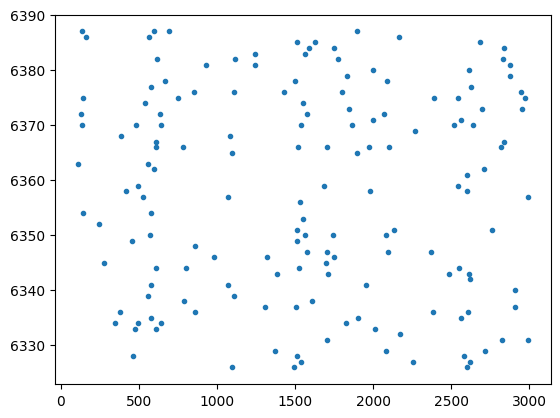

In [6]:
import matplotlib.pyplot as plt

spike_data = spike_rec.events
spike_senders = spike_data["senders"]
ts = spike_data["times"]
plt.figure(2)
plt.plot(ts, spike_senders, ".")
plt.show()